# Sérsic modelling of BCG and ICL components from IFU data

In [ ]:
import astrophot as ap
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from astropy.io import fits

In [ ]:
# If GPU is not available
# ap.AP_config.ap_device = "cpu"

In [ ]:
path = Path("~/data/ifu/2025-05-27/").expanduser()

In [ ]:
def plot_data_model_residual(
    target, model, mask, limits=None, binned=False, weight=False
):
    data = target.data.cpu()
    model = model()
    if binned:
        model_image = model.unbinned_data
        if weight:
            weight_image = target.unbinned_weight.cpu()
    else:
        model_image = model.data
        if weight:
            weight_image = target.weight.cpu()
    model_image = model_image.detach().cpu().numpy()
    ncol = 4 if weight else 3
    fig, ax = plt.subplots(
        1, ncol, figsize=(3 * ncol, 4), sharex=True, sharey=True, layout="compressed"
    )
    vmax = 0.5 * data.max()
    vmin = -0.5 * vmax
    ax[0].imshow(np.where(mask, np.nan, data), origin="lower", vmin=vmin, vmax=vmax)
    ax[1].imshow(model_image, origin="lower", vmin=vmin, vmax=vmax)
    ax[2].imshow(
        np.where(mask, np.nan, data - model_image), origin="lower", vmin=vmin, vmax=vmax
    )
    if weight:
        ax[3].imshow(weight_image, origin="lower")
    if limits is not None:
        ax[0].axis(limits)
    for a in ax:
        a.axvline(320.6, color="white", lw=0.5)
        a.axhline(181.1, color="white", lw=0.5)

In [ ]:
def get_data(filename):
    data = np.load(path / filename)
    return data


bins = np.load(path / "voronoi_mask_SN_150.npy")
bcg_data_raw = get_data("BCG_SB_map.npy")
icl_data_raw = get_data("ICL_SB_map.npy")
apoly_data = get_data("apoly_map.npy")
comp3_data = get_data("component_3_map.npy")

In [ ]:
total_data = bcg_data_raw + icl_data_raw + apoly_data + comp3_data
total_data -= np.nanmin(total_data)
bcg_fraction = bcg_data_raw / (bcg_data_raw + icl_data_raw)
bcg_data = total_data * bcg_fraction
icl_data = total_data * (1 - bcg_fraction)
bcg_mask = ~np.isfinite(bcg_data)
bcg_data[bcg_mask] = 0
icl_mask = ~np.isfinite(icl_data)
icl_data[icl_mask] = 0

/tmp/ipykernel_3016493/2046469198.py:3: RuntimeWarning: invalid value encountered in divide
  bcg_fraction = bcg_data_raw / (bcg_data_raw + icl_data_raw)


In [ ]:
output_path = path / "outputs/"
output_path.mkdir(exist_ok=True)
fits.writeto(output_path / "total_data.fits", total_data, overwrite=True)
fits.writeto(output_path / "bcg_data_raw.fits", bcg_data_raw, overwrite=True)
fits.writeto(output_path / "icl_data_raw.fits", icl_data_raw, overwrite=True)
fits.writeto(output_path / "bcg_data.fits", bcg_data, overwrite=True)
fits.writeto(output_path / "icl_data.fits", icl_data, overwrite=True)

(220.0, 420.0, 80.0, 280.0)

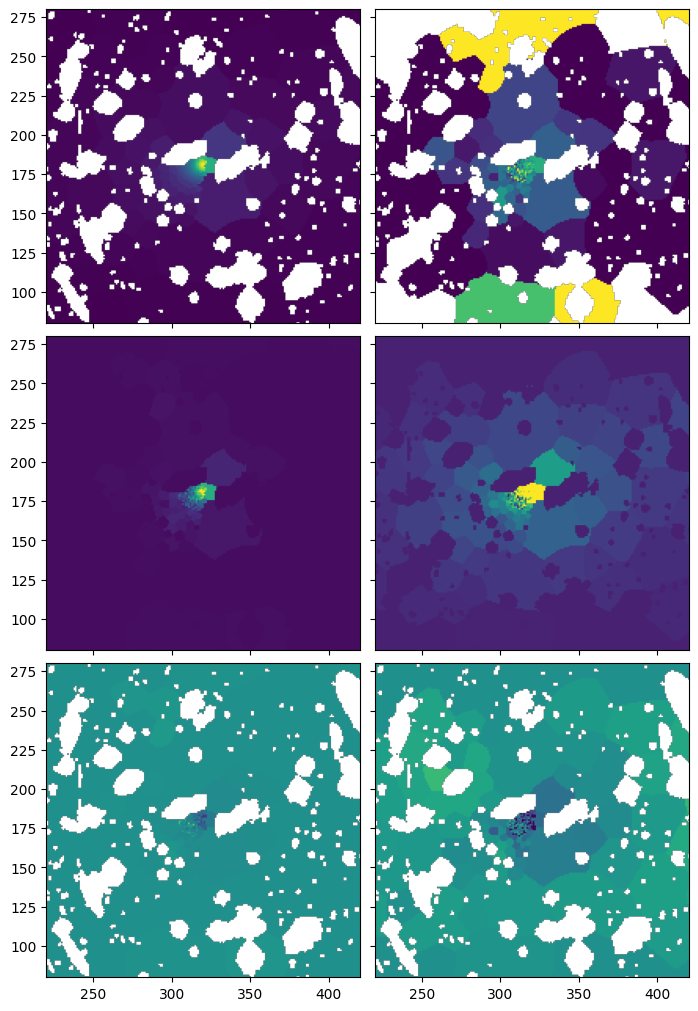

In [ ]:
fig, ax = plt.subplots(
    3, 2, figsize=(10, 10), sharex=True, sharey=True, layout="compressed"
)
ax[0, 0].imshow(total_data, origin="lower")
ax[0, 1].imshow(bcg_fraction, origin="lower")
ax[1, 0].imshow(bcg_data, origin="lower", vmin=-1, vmax=30)
ax[1, 1].imshow(icl_data, origin="lower", vmin=-1, vmax=10)
ax[2, 0].imshow(bcg_data - bcg_data_raw, origin="lower", vmin=-6, vmax=6)
ax[2, 1].imshow(icl_data - icl_data_raw, origin="lower", vmin=-2, vmax=2)
ax[0, 0].axis((220, 420, 80, 280))

In [ ]:
bcg_initial_params = {
    "center": [320, 180],
    "q": 0.6,
    "PA": 90 * np.pi / 180,
    "n": 2.0,
    "Re": 5.0,
    "Ie": 1.0,
}

icl_initial_params = {
    "center": [320, 180],
    "q": 0.6,
    "PA": 90 * np.pi / 180,
    "n": 2.0,
    "Re": 20.0,
    "Ie": 0.5,
}

## Fit to pixels with $1/N_\textrm{bin}$ weights

In [ ]:
bin_weights = np.zeros_like(bins, dtype=np.float32)
bin_indexes = np.unique(bins)
for idx in bin_indexes:
    n = np.sum(bins == idx)
    if n > 0:
        bin_weights[bins == idx] = 1 / n

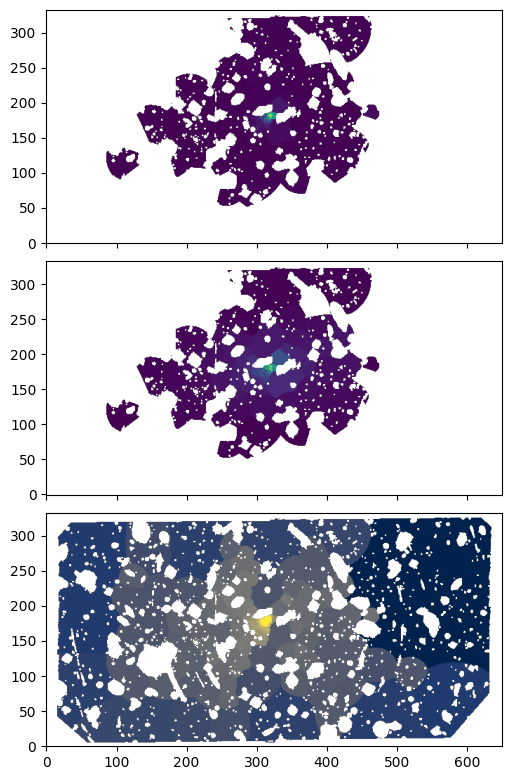

In [ ]:
fig, ax = plt.subplots(
    3, 1, figsize=(5, 15), sharex=True, sharey=True, layout="compressed"
)
ax[0].imshow(np.where(bcg_mask, np.nan, bcg_data), origin="lower")
ax[1].imshow(np.where(icl_mask, np.nan, icl_data), origin="lower")
ax[2].imshow(bin_weights, origin="lower", norm="log", cmap="cividis");

### Fit the BCG with free parameters

In [ ]:
bcg_target = ap.image.Target_Image(
    data=bcg_data, mask=bcg_mask, weight=bin_weights, pixelscale=1
)

In [ ]:
bcg_model = ap.models.AstroPhot_Model(
    name="bcg",
    model_type="sersic galaxy model",
    parameters=bcg_initial_params,
    target=bcg_target,
)
bcg_model.initialize()

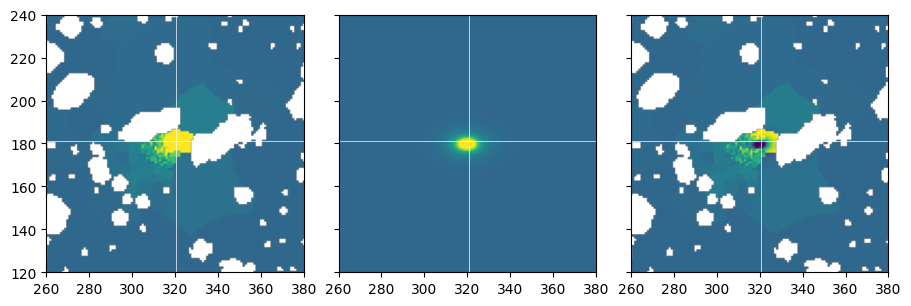

In [ ]:
plot_data_model_residual(bcg_target, bcg_model, bcg_mask, limits=(260, 380, 120, 240))

In [ ]:
bcg_result = ap.fit.LM(bcg_model).fit()
bcg_result.update_uncertainty()

In [ ]:
bcg_model.parameters

bcg (id-140040135727664, branch node):
  center (id-140040095828112): [320.7124240124103, 181.2526798263613] +- [0.10276398803370622, 0.06435840523612789] [arcsec]
  q (id-140040134117424): 0.8453189459317292 +- 0.023730948262085723 [b/a], limits: (0.0, 1.0)
  PA (id-140040137717136): 1.968888736406297 +- 0.06950150152610338 [radians], limits: (0.0, 3.141592653589793), cyclic
  n (id-140040133545712): 0.9823315806178573 +- 0.03180289705952688 [none], limits: (0.36, 8.0)
  Re (id-140040135722480): 11.412593468124872 +- 0.3189205104044711 [arcsec], limits: (0.0, None)
  Ie (id-140040141981024): 0.8349201175753851 +- 0.020246204348032943 [log10(flux/arcsec^2)]

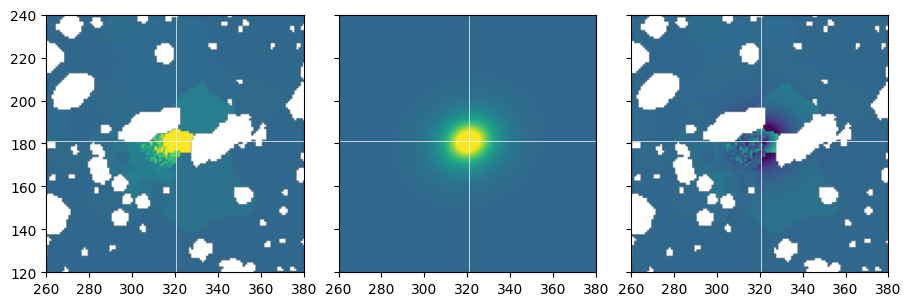

In [ ]:
plot_data_model_residual(bcg_target, bcg_model, bcg_mask, limits=(260, 380, 120, 240))

### Fit the ICL

In [ ]:
icl_target = ap.image.Target_Image(
    data=icl_data, mask=icl_mask, weight=bin_weights, pixelscale=1
)

#### With free parameters

In [ ]:
icl_model = ap.models.AstroPhot_Model(
    name="icl",
    model_type="sersic galaxy model",
    parameters=icl_initial_params,
    target=icl_target,
)
icl_model.initialize()

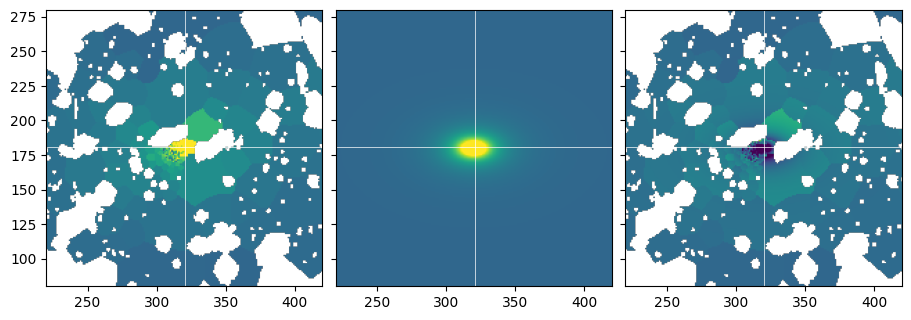

In [ ]:
plot_data_model_residual(icl_target, icl_model, icl_mask, limits=(220, 420, 80, 280))

In [ ]:
icl_result = ap.fit.LM(icl_model).fit()
icl_result.update_uncertainty()

In [ ]:
icl_model.parameters

icl (id-140038464271088, branch node):
  center (id-140038465750896): [320.84495874303514, 182.77914724171958] +- [0.34042023449770326, 0.24246874476397215] [arcsec]
  q (id-140038422385520): 0.5577992823920488 +- 0.04516272294601776 [b/a], limits: (0.0, 1.0)
  PA (id-140040133404160): 0.890906667661155 +- 0.05360954836345189 [radians], limits: (0.0, 3.141592653589793), cyclic
  n (id-140038461655280): 1.213174765957515 +- 0.06563908701716582 [none], limits: (0.36, 8.0)
  Re (id-140038458916592): 43.659735014186595 +- 4.579262179438641 [arcsec], limits: (0.0, None)
  Ie (id-140038458906992): 0.37497059487109874 +- 0.04472420416103308 [log10(flux/arcsec^2)]

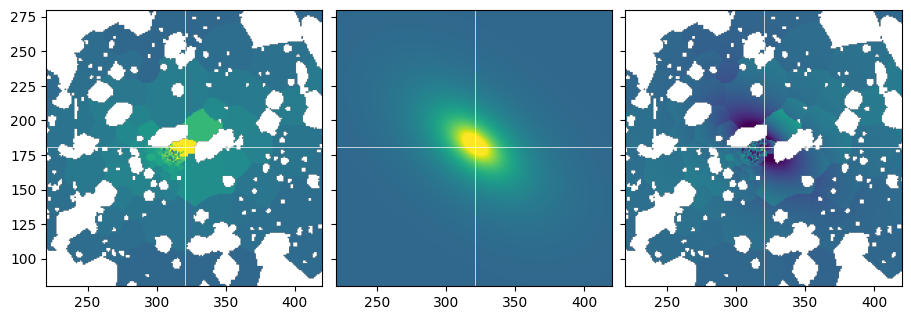

In [ ]:
plot_data_model_residual(icl_target, icl_model, icl_mask, limits=(220, 420, 80, 280))

#### With centre fixed to BCG

In [ ]:
icl_centre_locked_initial_params = {
    "center": {"value": bcg_model.parameters["center"].value, "locked": True},
    "q": 0.6,
    "PA": 120 * np.pi / 180,
    "n": 1,
    "Re": 30,
    "Ie": 0.5,
}
icl_centre_locked_model = ap.models.AstroPhot_Model(
    name="icl",
    model_type="sersic galaxy model",
    parameters=icl_centre_locked_initial_params,
    target=icl_target,
)
icl_centre_locked_model.initialize()

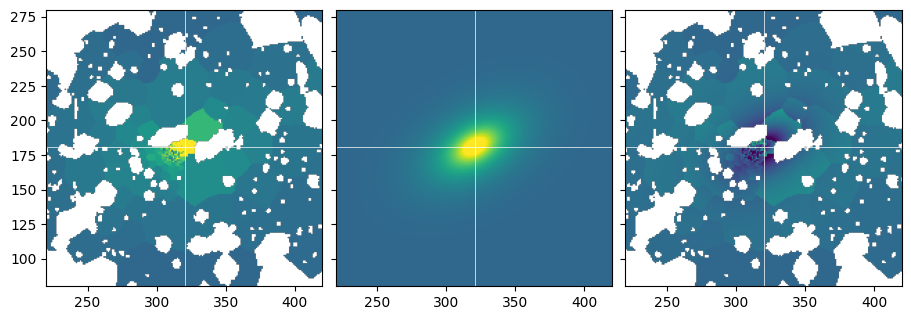

In [ ]:
plot_data_model_residual(
    icl_target, icl_centre_locked_model, icl_mask, limits=(220, 420, 80, 280)
)

In [ ]:
icl_centre_locked_result = ap.fit.LM(icl_centre_locked_model).fit()
icl_centre_locked_result.update_uncertainty()

In [ ]:
icl_centre_locked_model.parameters

icl (id-140038422684512, branch node):
  center (id-140038420454176): [320.7124240124103, 181.2526798263613] +- [0.1, 0.1] [arcsec], locked
  q (id-140038421802032): 0.46491807259584317 +- 0.033728861732555494 [b/a], limits: (0.0, 1.0)
  PA (id-140038421278176): 0.8390045893296882 +- 0.03805094152845615 [radians], limits: (0.0, 3.141592653589793), cyclic
  n (id-140038420447360): 1.2491867355797255 +- 0.06717606130294253 [none], limits: (0.36, 8.0)
  Re (id-140038422503088): 51.71907986720946 +- 5.3831118001851905 [arcsec], limits: (0.0, None)
  Ie (id-140038421803520): 0.3295451098263574 +- 0.04453248308624703 [log10(flux/arcsec^2)]

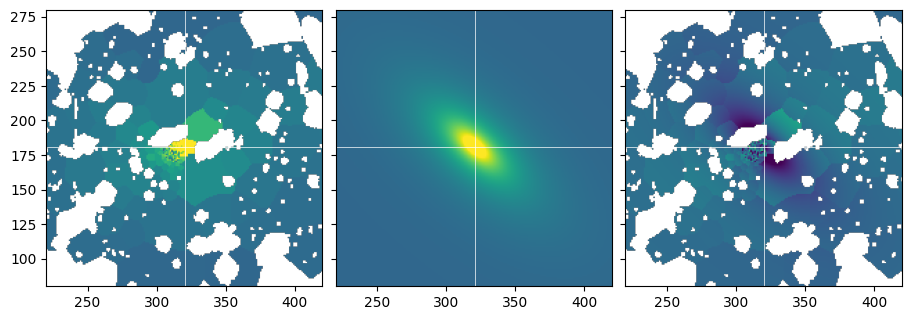

In [ ]:
plot_data_model_residual(
    icl_target, icl_centre_locked_model, icl_mask, limits=(220, 420, 80, 280)
)

## Binned fit with uniform weights

### Fit the BCG

In [ ]:
bcg_target_binned = ap.image.Target_Image(
    data=bcg_data, mask=bcg_mask, bins=bins, pixelscale=1
)

In [ ]:
bcg_model_binned = ap.models.AstroPhot_Model(
    name="bcg_binned",
    model_type="sersic galaxy model",
    parameters=bcg_initial_params,
    target=bcg_target_binned,
)
bcg_model_binned.initialize()

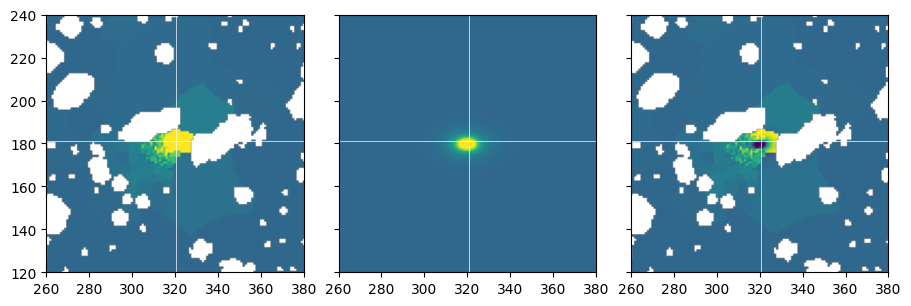

In [ ]:
plot_data_model_residual(
    bcg_target_binned, bcg_model_binned, bcg_mask, limits=(260, 380, 120, 240)
)

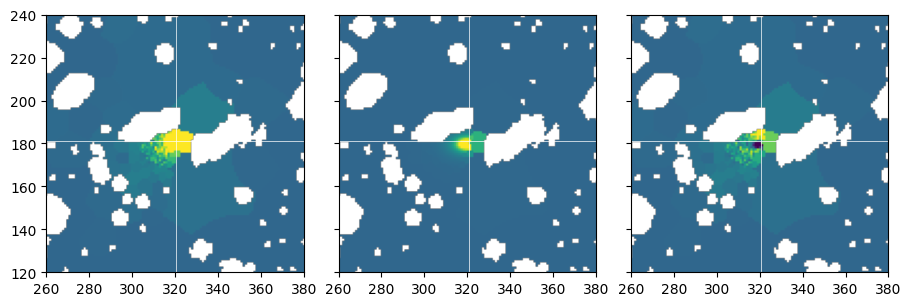

In [ ]:
plot_data_model_residual(
    bcg_target_binned,
    bcg_model_binned,
    bcg_mask,
    limits=(260, 380, 120, 240),
    binned=True,
)

In [ ]:
bcg_result = ap.fit.LM(bcg_model_binned).fit()
bcg_result.update_uncertainty()

In [ ]:
bcg_model_binned.parameters

bcg_binned (id-140271388185072, branch node):
  center (id-140271386220336): [320.8191121942091, 181.26930401108288] +- [0.10847889721875313, 0.06711307914804028] [arcsec]
  q (id-140271394036128): 0.8288618183713955 +- 0.023799449571145964 [b/a], limits: (0.0, 1.0)
  PA (id-140271386720976): 1.9632045054709044 +- 0.06319783895190165 [radians], limits: (0.0, 3.141592653589793), cyclic
  n (id-140271347561296): 0.9700976909278209 +- 0.03155792813015082 [none], limits: (0.36, 8.0)
  Re (id-140271389636656): 11.355612029989487 +- 0.30945324215593634 [arcsec], limits: (0.0, None)
  Ie (id-140271389637712): 0.846821908266195 +- 0.020192066906420145 [log10(flux/arcsec^2)]

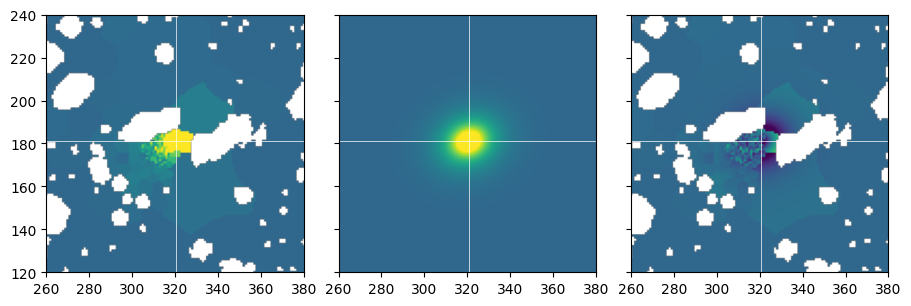

In [ ]:
plot_data_model_residual(
    bcg_target_binned, bcg_model_binned, bcg_mask, limits=(260, 380, 120, 240)
)

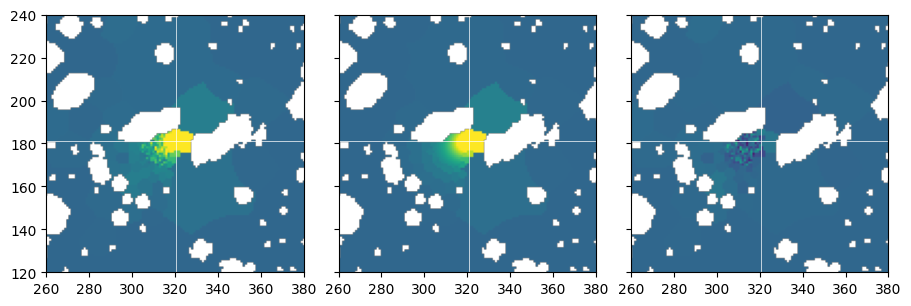

In [ ]:
plot_data_model_residual(
    bcg_target_binned,
    bcg_model_binned,
    bcg_mask,
    limits=(260, 380, 120, 240),
    binned=True,
)

### Fit the ICL

In [ ]:
icl_target_binned = ap.image.Target_Image(
    data=icl_data, mask=icl_mask, bins=bins, pixelscale=1
)

In [ ]:
icl_model_binned = ap.models.AstroPhot_Model(
    name="icl_binned",
    model_type="sersic galaxy model",
    parameters=icl_initial_params,
    target=icl_target_binned,
)
icl_model_binned.initialize()

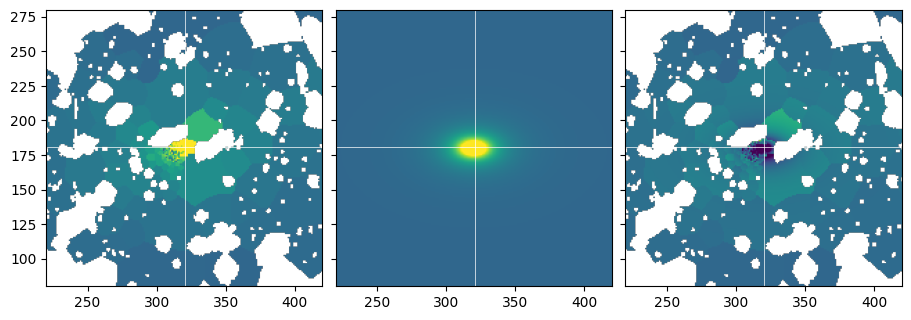

In [ ]:
plot_data_model_residual(
    icl_target_binned, icl_model_binned, icl_mask, limits=(220, 420, 80, 280)
)

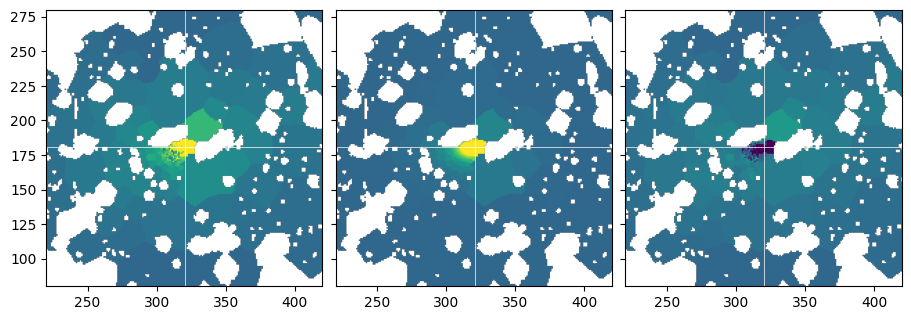

In [ ]:
plot_data_model_residual(
    icl_target_binned,
    icl_model_binned,
    icl_mask,
    limits=(220, 420, 80, 280),
    binned=True,
)

In [ ]:
icl_result = ap.fit.LM(icl_model_binned).fit()
icl_result.update_uncertainty()

In [ ]:
icl_model_binned.parameters

icl_binned (id-140268867264176, branch node):
  center (id-140269470490960): [320.9150943985411, 182.73390817074252] +- [0.3668285341140083, 0.265407843564274] [arcsec]
  q (id-140268865512624): 0.5376990656655197 +- 0.046464228896058744 [b/a], limits: (0.0, 1.0)
  PA (id-140268867730752): 0.8839153265634682 +- 0.05254676237289334 [radians], limits: (0.0, 3.141592653589793), cyclic
  n (id-140268868022160): 1.2003388716210828 +- 0.06594491459917359 [none], limits: (0.36, 8.0)
  Re (id-140268865512192): 44.428805159556035 +- 4.757638099796073 [arcsec], limits: (0.0, None)
  Ie (id-140268865510560): 0.38440619244920887 +- 0.044879999390146835 [log10(flux/arcsec^2)]

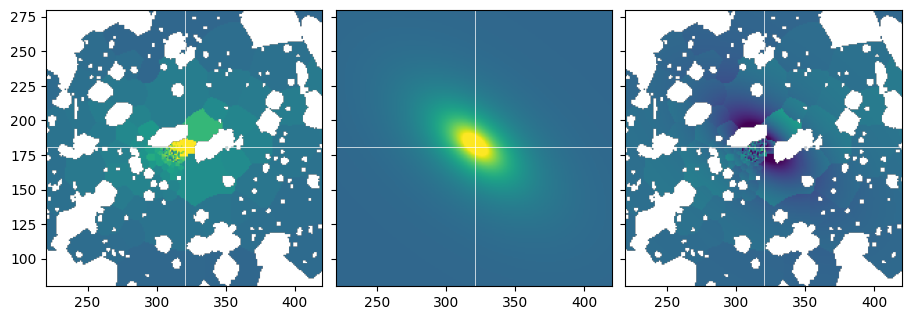

In [ ]:
plot_data_model_residual(
    icl_target_binned, icl_model_binned, icl_mask, limits=(220, 420, 80, 280)
)

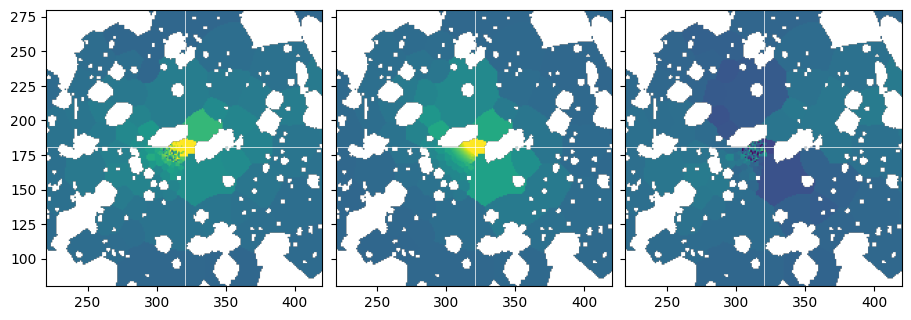

In [ ]:
plot_data_model_residual(
    icl_target_binned,
    icl_model_binned,
    icl_mask,
    limits=(220, 420, 80, 280),
    binned=True,
)

## Binned fit with constant relative errors

### Fit the BCG

In [ ]:
bcg_vars = np.maximum(1, (0.1 * bcg_data) ** 2)

In [ ]:
bcg_target_binned = ap.image.Target_Image(
    data=bcg_data, mask=bcg_mask, variance=bcg_vars, bins=bins, pixelscale=1
)

In [ ]:
bcg_model_binned = ap.models.AstroPhot_Model(
    name="bcg_binned",
    model_type="sersic galaxy model",
    parameters=bcg_initial_params,
    target=bcg_target_binned,
)
bcg_model_binned.initialize()

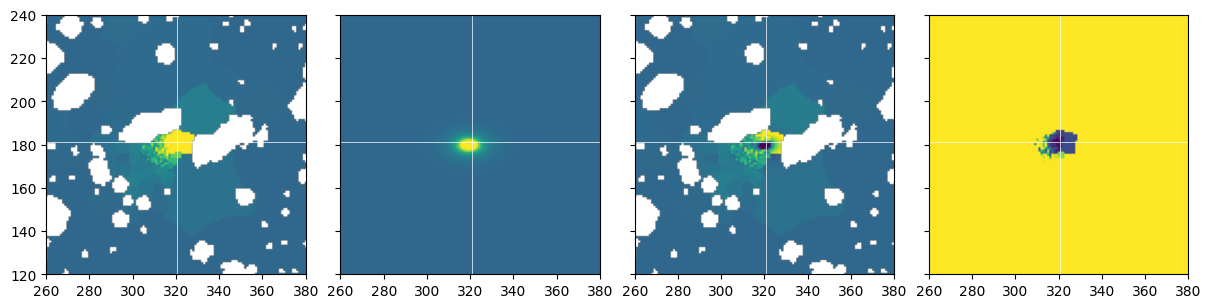

In [ ]:
plot_data_model_residual(
    bcg_target_binned,
    bcg_model_binned,
    bcg_mask,
    limits=(260, 380, 120, 240),
    weight=True,
)

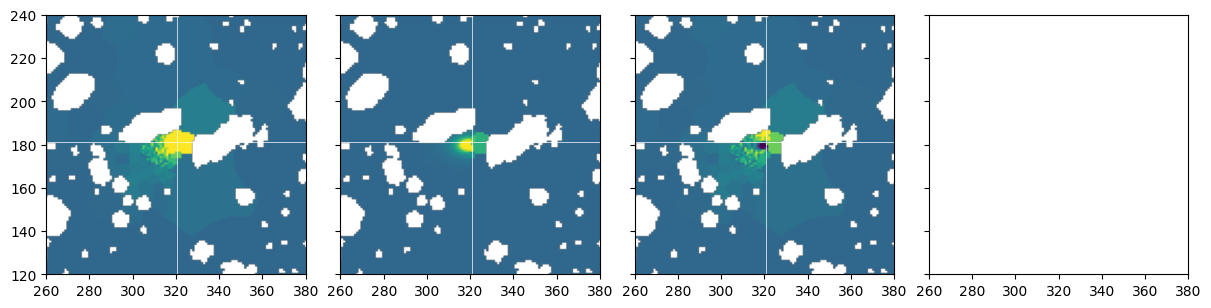

In [ ]:
plot_data_model_residual(
    bcg_target_binned,
    bcg_model_binned,
    bcg_mask,
    limits=(260, 380, 120, 240),
    binned=True,
    weight=True,
)

In [ ]:
bcg_result = ap.fit.LM(bcg_model_binned).fit()
bcg_result.update_uncertainty()

_LinAlgError: torch.linalg.solve: The solver failed because the input matrix is singular.

In [ ]:
bcg_model_binned.parameters

bcg_binned (id-140372885879600, branch node):
  center (id-140372285839920): [320.92430518051304, 181.16785401212525] +- [0.1899496132875242, 0.11066172562204085] [arcsec]
  q (id-140372285846832): 0.8089422775161041 +- 0.029664494903024023 [b/a], limits: (0.0, 1.0)
  PA (id-140372285840304): 1.9133542932201346 +- 0.07545894792375744 [radians], limits: (0.0, 3.141592653589793), cyclic
  n (id-140372953662336): 1.1784746883401556 +- 0.06551734447245074 [none], limits: (0.36, 8.0)
  Re (id-140372884970128): 11.349451982863194 +- 0.4843163349491095 [arcsec], limits: (0.0, None)
  Ie (id-140372286017504): 0.7954106141434101 +- 0.035136634435928946 [log10(flux/arcsec^2)]

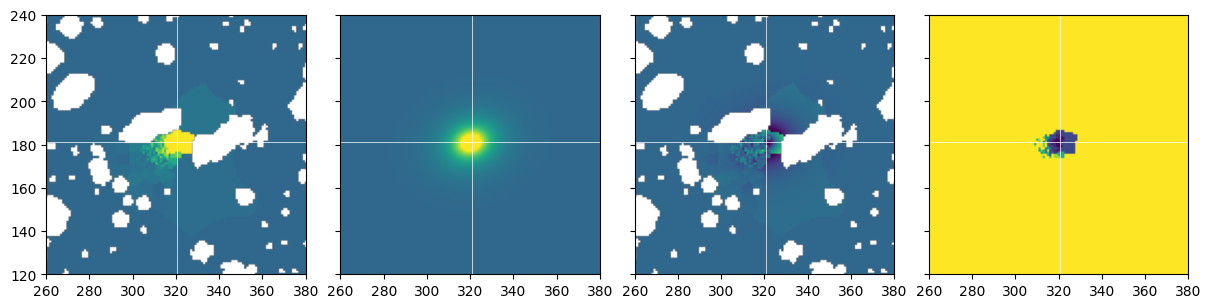

In [ ]:
plot_data_model_residual(
    bcg_target_binned,
    bcg_model_binned,
    bcg_mask,
    limits=(260, 380, 120, 240),
    weight=True,
)

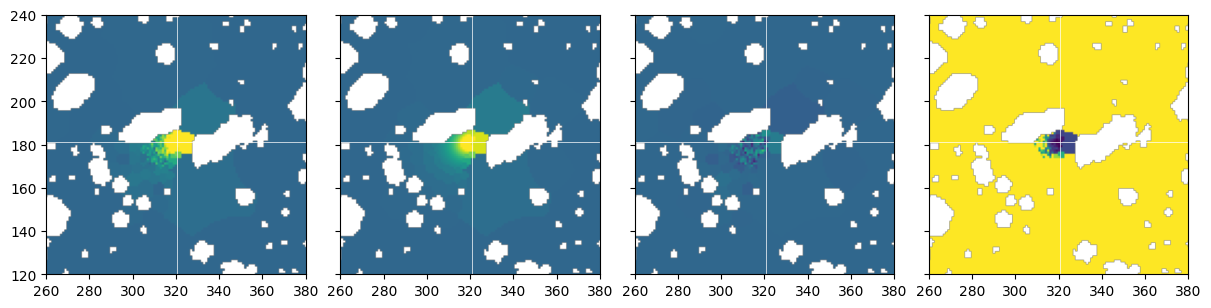

In [ ]:
plot_data_model_residual(
    bcg_target_binned,
    bcg_model_binned,
    bcg_mask,
    limits=(260, 380, 120, 240),
    binned=True,
    weight=True,
)

### Fit the ICL

In [ ]:
icl_vars = np.maximum(1, (0.1 * icl_data) ** 2)

In [ ]:
icl_target_binned = ap.image.Target_Image(
    data=icl_data, mask=icl_mask, variance=icl_vars, bins=bins, pixelscale=1
)

In [ ]:
icl_model_binned = ap.models.AstroPhot_Model(
    name="icl_binned",
    model_type="sersic galaxy model",
    parameters=icl_initial_params,
    target=icl_target_binned,
)
icl_model_binned.initialize()

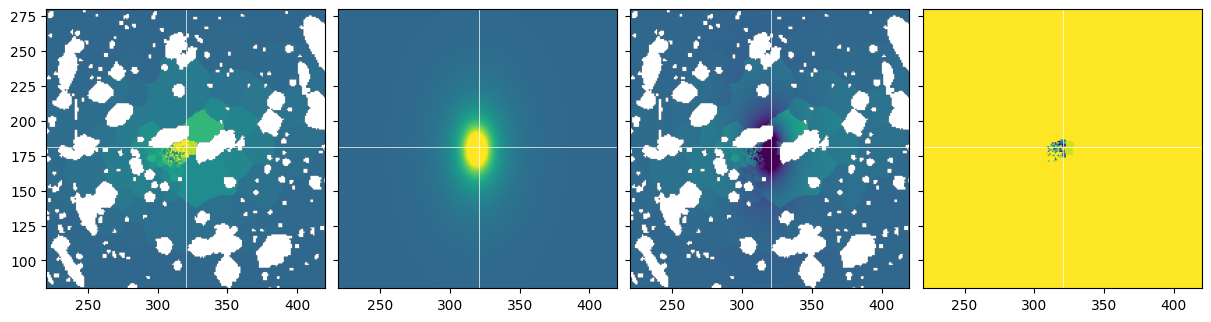

In [ ]:
plot_data_model_residual(
    icl_target_binned,
    icl_model_binned,
    icl_mask,
    limits=(220, 420, 80, 280),
    weight=True,
)

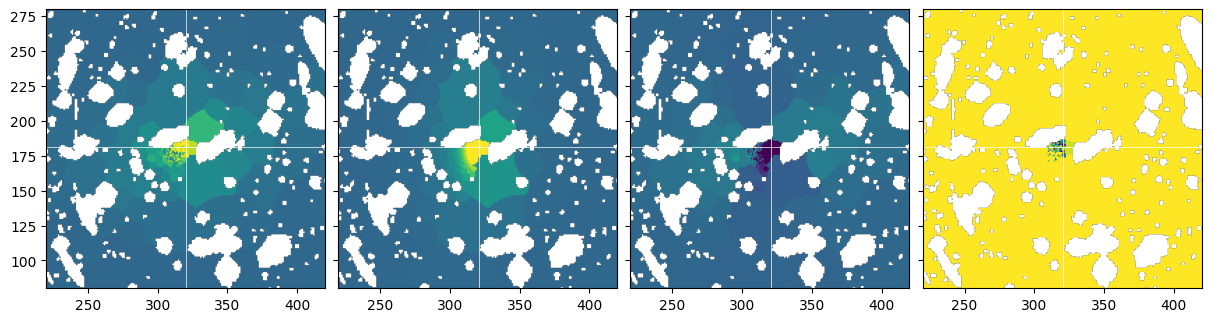

In [ ]:
plot_data_model_residual(
    icl_target_binned,
    icl_model_binned,
    icl_mask,
    limits=(220, 420, 80, 280),
    binned=True,
    weight=True,
)

In [ ]:
icl_result = ap.fit.LM(icl_model_binned).fit()
icl_result.update_uncertainty()

In [ ]:
icl_model_binned.parameters

icl_binned (id-140372983722112, branch node):
  center (id-140372957513920): [319.1653102148983, 185.81757499593684] +- [0.4500096864039561, 0.8204365269900091] [arcsec]
  q (id-140373087842336): 0.8205376732495114 +- 0.07796286004009499 [b/a], limits: (0.0, 1.0)
  PA (id-140372986302000): 0.8170553730460781 +- 0.21546960019194208 [radians], limits: (0.0, 3.141592653589793), cyclic
  n (id-140373088036208): 1.3348970976904178 +- 0.10637915657517161 [none], limits: (0.36, 8.0)
  Re (id-140372985980800): 44.52679187172376 +- 5.800960520173447 [arcsec], limits: (0.0, None)
  Ie (id-140372285704528): 0.2673632666350889 +- 0.06796097573250193 [log10(flux/arcsec^2)]

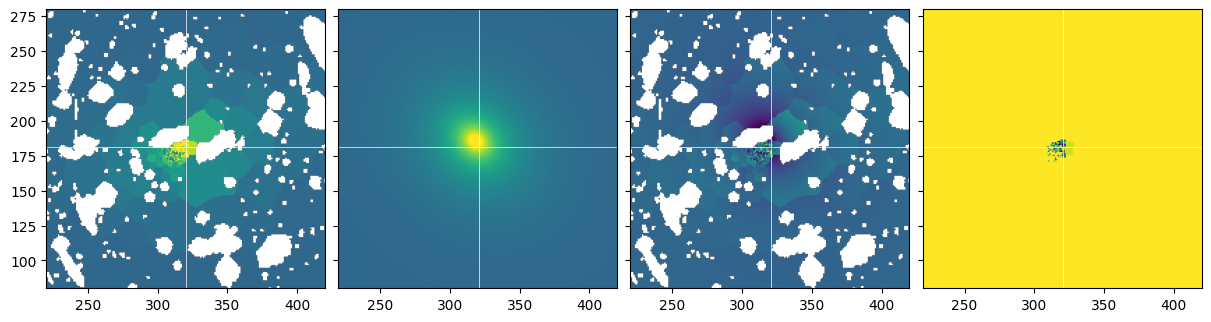

In [ ]:
plot_data_model_residual(
    icl_target_binned,
    icl_model_binned,
    icl_mask,
    limits=(220, 420, 80, 280),
    weight=True,
)

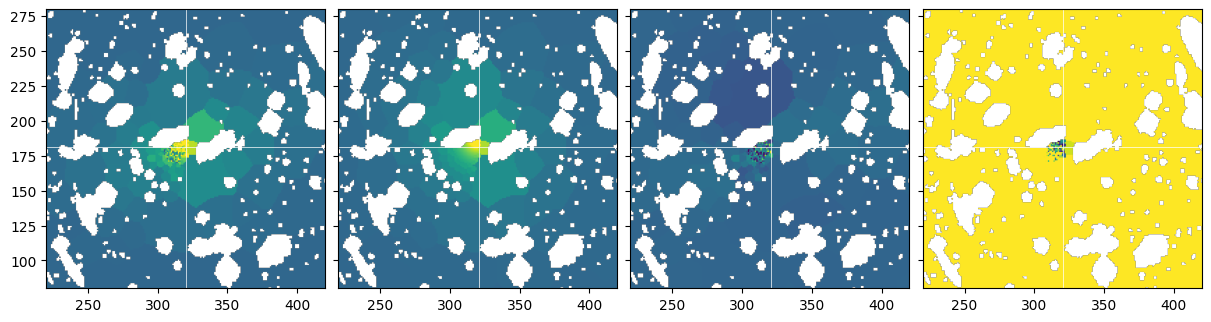

In [ ]:
plot_data_model_residual(
    icl_target_binned,
    icl_model_binned,
    icl_mask,
    limits=(220, 420, 80, 280),
    binned=True,
    weight=True,
)

## Binned fit with weights from component fraction

### Fit the BCG

In [ ]:
total = bcg_data + icl_data
min_total = 0.1
bcg_weight = bcg_data / total
bcg_weight[total < min_total] = 0.5
bcg_weight = np.clip(bcg_weight, 1e-6, 1 - 1e-6)
icl_weight = 1 - bcg_weight

/tmp/ipykernel_3016493/1211513310.py:3: RuntimeWarning: invalid value encountered in divide
  bcg_weight = bcg_data / total


<matplotlib.colorbar.Colorbar>

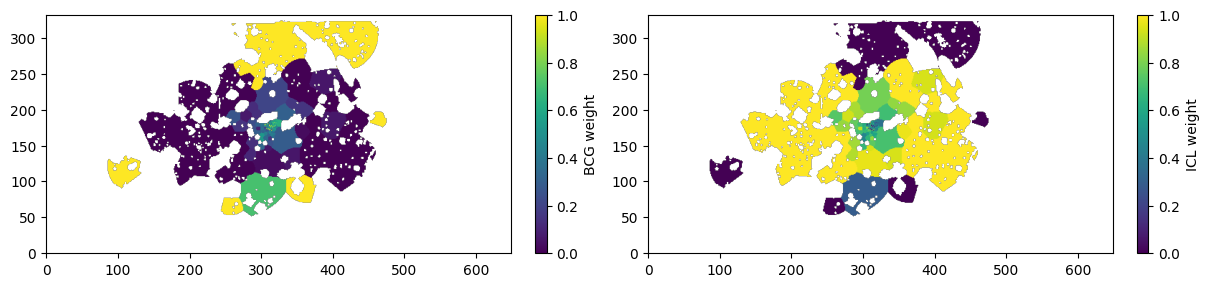

In [ ]:
plt.figure(figsize=(12, 4), layout="compressed")
plt.subplot(121)
plt.imshow(np.where(bcg_mask, np.nan, bcg_weight), origin="lower", vmin=0, vmax=1)
plt.colorbar(label="BCG weight")
plt.subplot(122)
plt.imshow(np.where(icl_mask, np.nan, icl_weight), origin="lower", vmin=0, vmax=1)
plt.colorbar(label="ICL weight")

In [ ]:
bcg_target_binned = ap.image.Target_Image(
    data=bcg_data, mask=bcg_mask, weight=bcg_weight, bins=bins, pixelscale=1
)

In [ ]:
bcg_model_binned = ap.models.AstroPhot_Model(
    name="bcg_binned",
    model_type="sersic galaxy model",
    parameters=bcg_initial_params,
    target=bcg_target_binned,
)
bcg_model_binned.initialize()

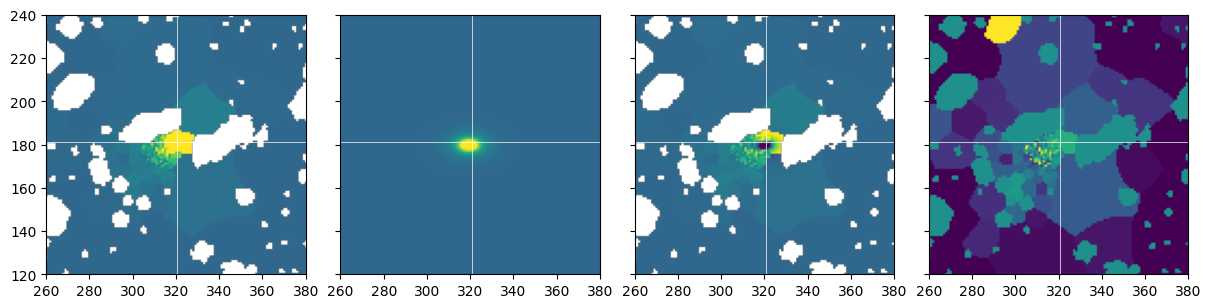

In [ ]:
plot_data_model_residual(
    bcg_target_binned,
    bcg_model_binned,
    bcg_mask,
    limits=(260, 380, 120, 240),
    weight=True,
)

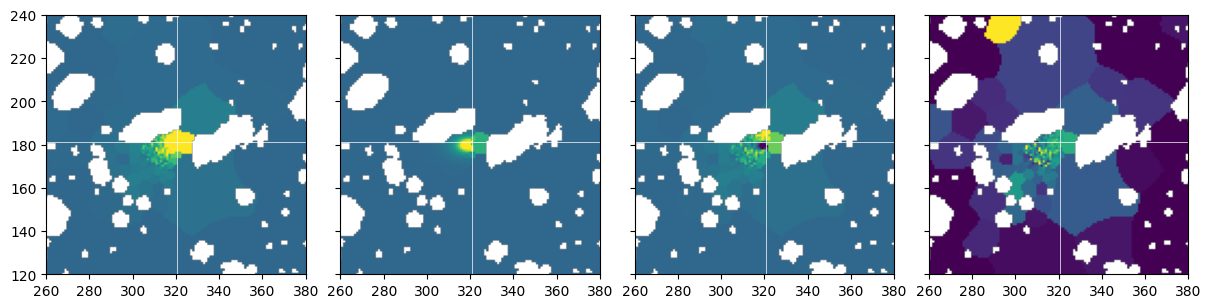

In [ ]:
plot_data_model_residual(
    bcg_target_binned,
    bcg_model_binned,
    bcg_mask,
    limits=(260, 380, 120, 240),
    binned=True,
    weight=True,
)

In [ ]:
bcg_result = ap.fit.LM(bcg_model_binned).fit()
bcg_result.update_uncertainty()

In [ ]:
bcg_model_binned.parameters

bcg_binned (id-140268860828720, branch node):
  center (id-140268860433872): [320.8229012980509, 181.24742058845985] +- [0.13838453608386955, 0.08833287460175132] [arcsec]
  q (id-140268860433728): 0.8179197894208429 +- 0.03187728382213075 [b/a], limits: (0.0, 1.0)
  PA (id-140268860818880): 1.9420594509667959 +- 0.08193132740441265 [radians], limits: (0.0, 3.141592653589793), cyclic
  n (id-140268865050992): 1.0357121304823607 +- 0.046748877209084494 [none], limits: (0.36, 8.0)
  Re (id-140268862501808): 13.450361889383776 +- 0.6169411986901476 [arcsec], limits: (0.0, None)
  Ie (id-140268859721968): 0.7962319479814195 +- 0.03059442200681481 [log10(flux/arcsec^2)]

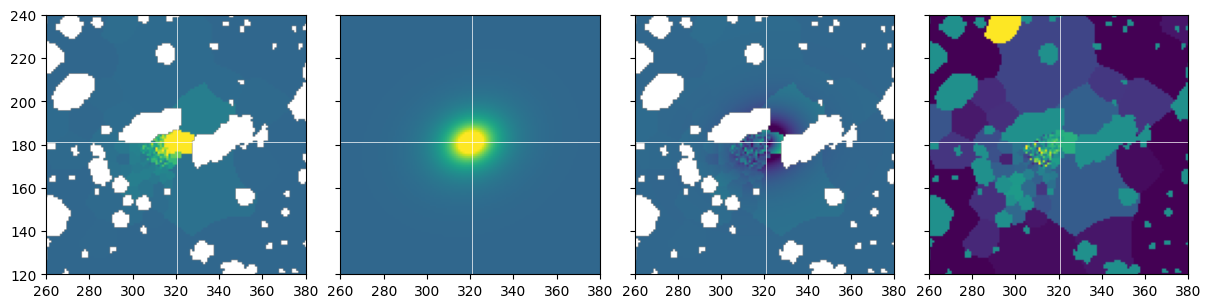

In [ ]:
plot_data_model_residual(
    bcg_target_binned,
    bcg_model_binned,
    bcg_mask,
    limits=(260, 380, 120, 240),
    weight=True,
)

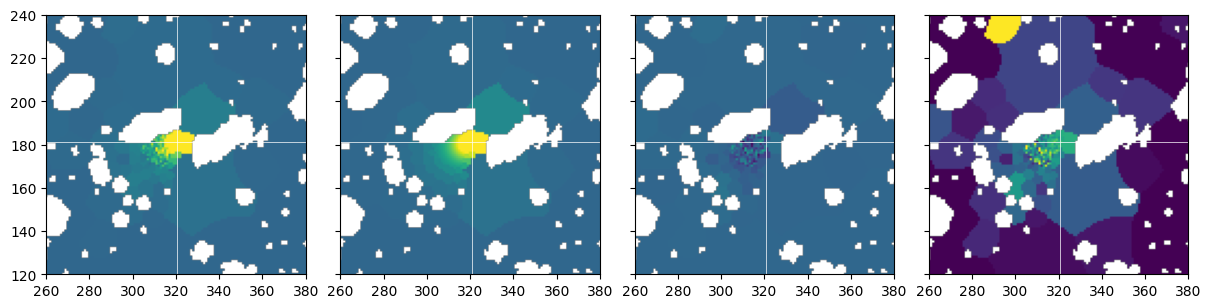

In [ ]:
plot_data_model_residual(
    bcg_target_binned,
    bcg_model_binned,
    bcg_mask,
    limits=(260, 380, 120, 240),
    binned=True,
    weight=True,
)

### Fit the ICL

In [ ]:
icl_target_binned = ap.image.Target_Image(
    data=icl_data, mask=icl_mask, weight=icl_weight, bins=bins, pixelscale=1
)

In [ ]:
icl_model_binned = ap.models.AstroPhot_Model(
    name="icl_binned",
    model_type="sersic galaxy model",
    parameters=icl_initial_params,
    target=icl_target_binned,
)
icl_model_binned.initialize()

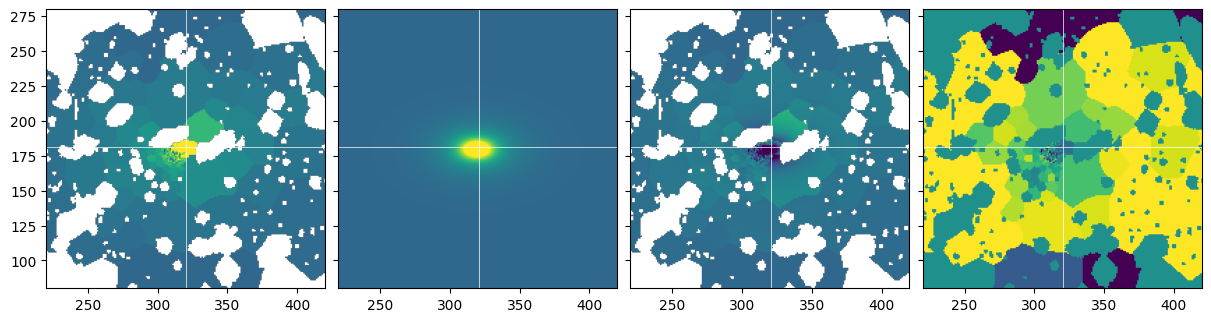

In [ ]:
plot_data_model_residual(
    icl_target_binned,
    icl_model_binned,
    icl_mask,
    limits=(220, 420, 80, 280),
    weight=True,
)

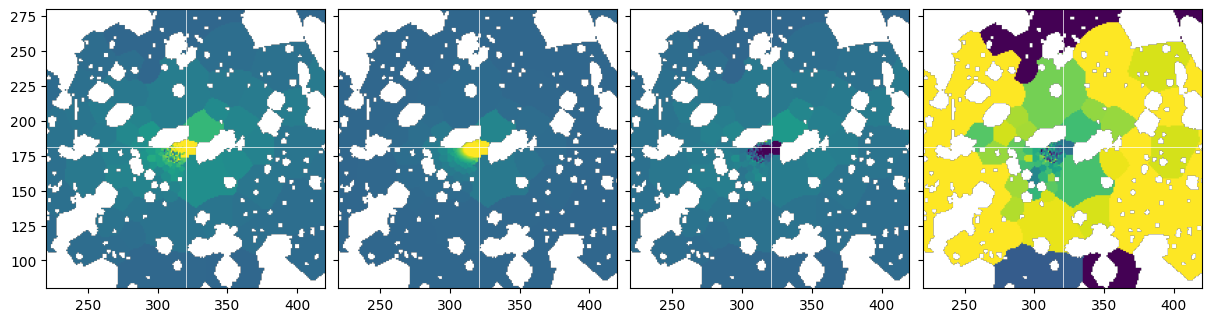

In [ ]:
plot_data_model_residual(
    icl_target_binned,
    icl_model_binned,
    icl_mask,
    limits=(220, 420, 80, 280),
    binned=True,
    weight=True,
)

In [ ]:
icl_result = ap.fit.LM(icl_model_binned).fit()
icl_result.update_uncertainty()

In [ ]:
icl_model_binned.parameters

icl_binned (id-140268855853520, branch node):
  center (id-140268854593968): [320.9785997942192, 182.79117342633748] +- [0.5757846445374037, 0.3533106781876334] [arcsec]
  q (id-140268857069440): 0.6772065174170596 +- 0.060531640273166466 [b/a], limits: (0.0, 1.0)
  PA (id-140268854424016): 1.037776716940286 +- 0.11388899301207843 [radians], limits: (0.0, 3.141592653589793), cyclic
  n (id-140268860424704): 1.1685396034226767 +- 0.08564715159145836 [none], limits: (0.36, 8.0)
  Re (id-140268857066560): 39.681796661081925 +- 4.623385174095743 [arcsec], limits: (0.0, None)
  Ie (id-140268856579840): 0.4149864516743364 +- 0.05820038703575185 [log10(flux/arcsec^2)]

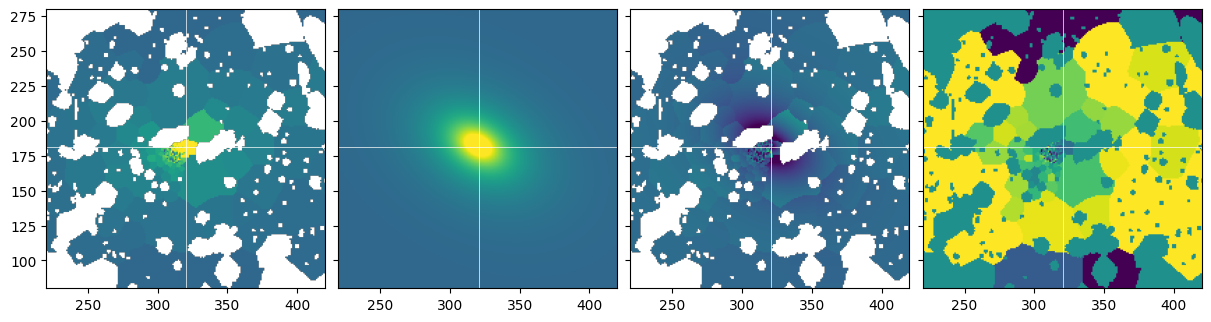

In [ ]:
plot_data_model_residual(
    icl_target_binned,
    icl_model_binned,
    icl_mask,
    limits=(220, 420, 80, 280),
    weight=True,
)

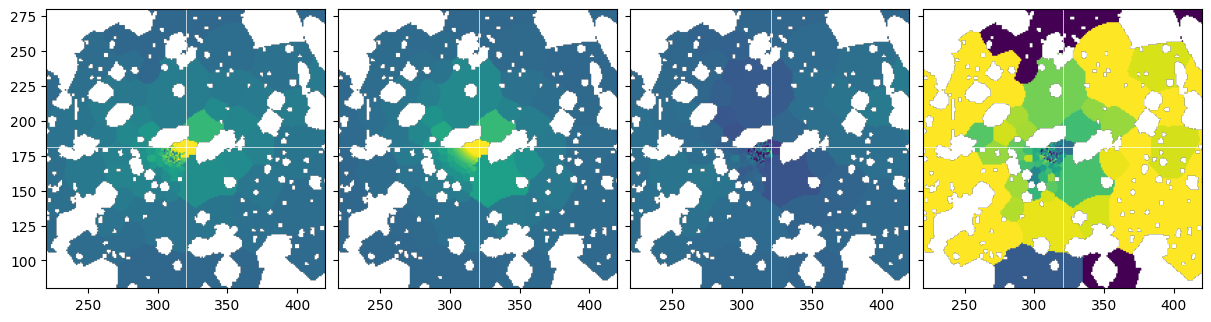

In [ ]:
plot_data_model_residual(
    icl_target_binned,
    icl_model_binned,
    icl_mask,
    limits=(220, 420, 80, 280),
    binned=True,
    weight=True,
)